loading all the libraries :)

In [1]:
import torch
import torch.nn as nn
import torchvision.models as models
from torch.utils.data import DataLoader
from torchvision import transforms,datasets
from torch.cuda.amp import autocast, GradScaler
import time


loading the datasets :)

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [3]:
transform_train = transforms.Compose([transforms.Grayscale(),transforms.Resize((48,48)),transforms.RandomHorizontalFlip(p=0.5),transforms.RandomRotation(10),transforms.ToTensor(),transforms.Normalize([0.5],[0.5])])
train_data = datasets.ImageFolder("train_test/train",transform_train)
train_loader = DataLoader(train_data,batch_size=64,shuffle=True)

transform_test = transforms.Compose([transforms.Grayscale(),transforms.Resize((48,48)),transforms.ToTensor(),transforms.Normalize([0.5],[0.5])])
test_data = datasets.ImageFolder("train_test/train",transform_test)
test_loader = DataLoader(train_data,batch_size=64,shuffle=True)


img,label = next(iter(train_loader))
print(f"the image shape is {img.shape} and the label shape is {label.shape}")

the image shape is torch.Size([64, 1, 48, 48]) and the label shape is torch.Size([64])


declare the model :(

In [4]:



class Emotion(nn.Module):
    def __init__(self):
        super(Emotion,self).__init__()
        vgg = models.vgg13(pretrained=True)
        vgg.features[0] = nn.Conv2d(1, 64, 3,1, padding =1)
        self.features = vgg.features
        self.avgpool = vgg.avgpool
        self.classifier = nn.Sequential(nn.Linear(512*7*7, 256),nn.ReLU(),nn.Dropout(0.5),nn.Linear(256, 7))

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = x.view(x.size(0), -1)
        x= self.classifier(x)
        return x

model = Emotion()
model = model.to(device)



for name, param in model.named_parameters():
    param.data = param.data.float()
for name, buf in model.named_buffers():
    buf.data = buf.data.float()



C:\Users\Albert\PycharmProjects\emotion_cnn\.venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\Albert\PycharmProjects\emotion_cnn\.venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG13_Weights.IMAGENET1K_V1`. You can also use `weights=VGG13_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


initialize the loss and the optimizer + scheduler

In [5]:
crit = nn.CrossEntropyLoss()
optim = torch.optim.AdamW(model.parameters(),lr=1e-4,weight_decay=1e-4)
scaler = torch.amp.GradScaler("cuda")
#scheduler = torch.optim.lr_scheduler()

we train the model

In [6]:


epoch = 20
start_time = time.time()
train_losses=[]
for i in range(epoch):

    trn_corr = 0
    trn_loss = 0
    avg_loss = 0
    model.train()
    for b ,(img,label) in enumerate(train_loader):

        b+=1
        img , label = img.to(device), label.to(device)
        optim.zero_grad()


        with torch.amp.autocast("cuda"):
            output = model(img)
            loss = crit(output, label)

        scaler.scale(loss).backward()
        scaler.step(optim)
        scaler.update()

        pred = output.argmax(dim=1)
        avg_loss += loss.item()
        trn_loss += loss.item()
        trn_corr += pred.eq(label).sum().item()
        if b%100 ==0:
            print(f"batch {b} completed ||  loss--> {avg_loss/b}")
            avg_loss = 0

    train_losses.append(trn_loss/len(train_loader))

    train_acc = (trn_corr / len(train_loader.dataset)) * 100
    print(f"epoch-->{i}/{epoch} || loss-->{trn_loss/len(train_loader)} || acc-->{train_acc} %  ")

end_time = time.time()
print(f"total time taken --> {(end_time - start_time)/60} minutes")


KeyboardInterrupt: 

now we judge the model

In [85]:
tst_corr=0
tst_loss =[]
with torch.no_grad():
    for b,(img,label) in enumerate(test_loader):
        img , label = img.to(device),label.to(device)
        output = model(img)
        pred = output.argmax(dim=1)
        tst_corr += pred.eq(label).sum().item()

print(f"accuracy--> {tst_corr/len(test_loader.dataset) * 100}%")

accuracy--> 93.18680553136647%


save the model for further labour :o

In [81]:
torch.save(model.state_dict(), 'fer_emotion_vgg2.pth')

plot

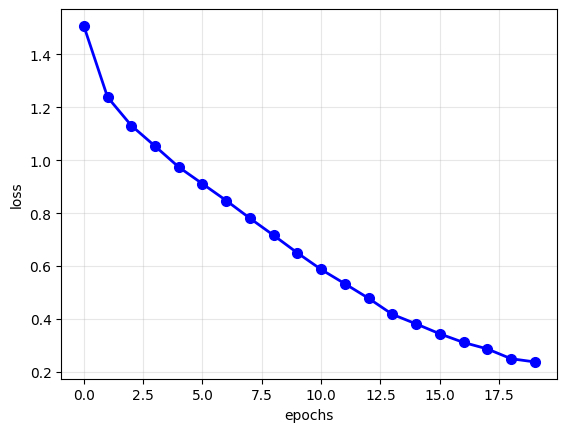

In [84]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(train_losses,'b-o',markersize = 7,linewidth=2)
plt.xlabel('epochs')
plt.ylabel('loss')
plt.grid(True ,alpha=0.3)
plt.pause(0.1)
plt.show()